# Task 1: Reproducing the official baseline

**Goal.** Recompute the three published indicators from the raw data, explain any gap, then show where and when
coverage degrades and which centre answers first in each commune.

**Rules from the business guide** (`docs/notice_metier.md`, not up for debate):
- Response time runs from the alert to the **first vehicle to arrive**, whatever its type.
- An intervention with no arrival is **unfulfilled**. It stays in the delay indicators with **60 min**.
- **On time** means delay ≤ threshold for the zone and reason. **Z4** has no target and is left out of the rate.

In [1]:
import pandas as pd
import helpers as h
import figures as fg

raw = h.load_raw()   # the six files from raw_data/, an untouched copy of donnees/
pd.DataFrame({name: df.shape for name, df in raw.items()}, index=["rows", "columns"]).T

,rows,columns
interventions,74215,9
communes,120,5
centres,30,6
plan_deploiement,960,3
seuils_reglementaires,12,3
baseline_officielle,3,2


## 1. First look at the data

Only the checks the calculation depends on.

In [2]:
iv = raw["interventions"]
by_id = iv.groupby("id_intervention")
multi = by_id.size()[lambda s: s > 1].index
arrived = iv.dropna(subset=["horodatage_arrivee"]).sort_values("horodatage_arrivee", kind="stable")
first_listed = iv.reset_index().groupby("id_intervention")["index"].min()
first_arrived = arrived.reset_index().groupby("id_intervention")["index"].first()
no_arrival = iv.loc[iv["horodatage_arrivee"].isna(), "id_intervention"].unique()
gap_s = ((arrived["horodatage_arrivee"] - arrived["horodatage_alerte"]).dt.total_seconds()
         - (arrived["delai_depart_min"] * 60 + arrived["duree_trajet_s"])).abs().max()

pd.Series({
    "Vehicle rows": len(iv),
    "Interventions (unique ids)": iv["id_intervention"].nunique(),
    "Exact duplicate rows": iv.duplicated().sum(),
    "Ids with several alert times, communes or reasons": sum(
        (by_id[c].nunique() > 1).sum() for c in ["horodatage_alerte", "insee", "raison"]),
    "Interventions with 2 or 3 vehicles": len(multi),
    "  of which the first row is not the first arrival": (first_listed[multi] != first_arrived.reindex(multi)).sum(),
    "Interventions with no arrival": len(no_arrival),
    "  of which another vehicle still arrived": iv[iv["id_intervention"].isin(no_arrival)]["horodatage_arrivee"].notna().sum(),
    "Vehicle types that ever arrive first": ", ".join(arrived.drop_duplicates("id_intervention")["type_engin"].unique()),
    "Max gap, timestamps vs duration columns (s)": round(gap_s, 1),
}).to_frame("value")

,value
Vehicle rows,74215
Interventions (unique ids),55000
Exact duplicate rows,0
"Ids with several alert times, communes or reasons",0
Interventions with 2 or 3 vehicles,12796
of which the first row is not the first arrival,7458
Interventions with no arrival,672
of which another vehicle still arrived,0
Vehicle types that ever arrive first,"VSAV, FPT"
"Max gap, timestamps vs duration columns (s)",1.6


In [3]:
display(pd.crosstab(iv["raison"], iv["type_engin"], margins=True))
raw["seuils_reglementaires"].pivot(index="zone_sdacr", columns="raison", values="seuil_min")   # thresholds (min)

type_engin,CCR,FPT,VSAV,VTU,All
raison,,,,,
AVP,855,841,7390,861,9947
INC,1933,11981,1978,2028,17920
SAP,1880,1966,40501,2001,46348
All,4668,14788,49869,4890,74215


raison,AVP,INC,SAP
zone_sdacr,,,
Z1,40.0,20.0,20.0
Z2,40.0,25.0,20.0
Z3,40.0,30.0,20.0
Z4,NaN,NaN,NaN


**What this means for the calculation**
- One id is one intervention: no duplicates, and each id has one alert, one commune and one reason.
- There is no dispatch rank, and in 7,458 of the 12,796 multi-vehicle interventions the first row is not the first
  arrival. So the first vehicle is found by **earliest arrival time**, never by row order.
- The 672 interventions with no arrival have no other vehicle at all. They are the unfulfilled ones.
- Only VSAV and FPT ever arrive first, as the guide says, so keeping all vehicle types changes nothing.
- Z4 has no threshold, which matches the rule that Z4 is left out of the compliance rate.

## 2. One row per intervention

In [4]:
interventions = h.build_interventions(raw)   # delay = arrival time minus alert time, of the first vehicle
interventions.to_csv(h.DATA / "first_arrivals.csv", index=False)
interventions.head(3)

,id_intervention,alert_time,insee,reason,n_vehicles,first_vehicle,first_centre,observed_delay_min,unfulfilled,delay_min,zone,threshold_min,compliant
0,I000000,2025-01-01 00:28:20,25106,SAP,1,VSAV,CIS07,6.250000,False,6.250000,Z2,20.0,True
1,I000001,2025-01-01 00:30:36,25082,SAP,1,VSAV,CIS27,3.983333,False,3.983333,Z1,20.0,True
2,I000002,2025-01-01 00:40:08,25021,SAP,1,VSAV,CIS23,13.366667,False,13.366667,Z2,20.0,True


## 3. The three indicators against the official values

In [5]:
check = h.compare_to_baseline(h.compute_kpis(interventions), raw["baseline_officielle"])
check.round(4).to_csv(h.RESULTS / "kpi_check.csv")
check.round(4)

,official,recomputed,gap
indicator,,,
p90_delai_sap_min,25.51,25.5100,-0.0000
inc_non_honorees,290.00,290.0000,0.0000
taux_conformite_pct,86.45,86.4605,0.0105


## 4. Why compliance shows 86.46 and not 86.45

In [6]:
durations = h.build_interventions(raw, delay_source="durations")
pd.DataFrame({
    "official": check["official"],
    "from timestamps": check["recomputed"],
    "from duration columns": pd.Series(h.compute_kpis(durations)),
}).round(3)

,official,from timestamps,from duration columns
p90_delai_sap_min,25.51,25.510,25.503
inc_non_honorees,290.00,290.000,290.000
taux_conformite_pct,86.45,86.461,86.451


The delay can be read from the timestamps (rounded to the second) or from the duration columns (finer).
Seven interventions sit within one second of their threshold, so that rounding decides their verdict.
Each source matches two indicators and misses the third only through this sub-second rounding, so the gap comes
from the data's precision, not from the method. I keep the timestamps because they follow the guide's wording: alert to arrival.

## 5. Where and when coverage degrades

,nom_commune,zone_sdacr,n,late_pct
insee,,,,
25066,COM066,Z3,211,91.0
25063,COM063,Z3,327,89.9
25025,COM025,Z3,331,88.5
25015,COM015,Z3,208,88.5


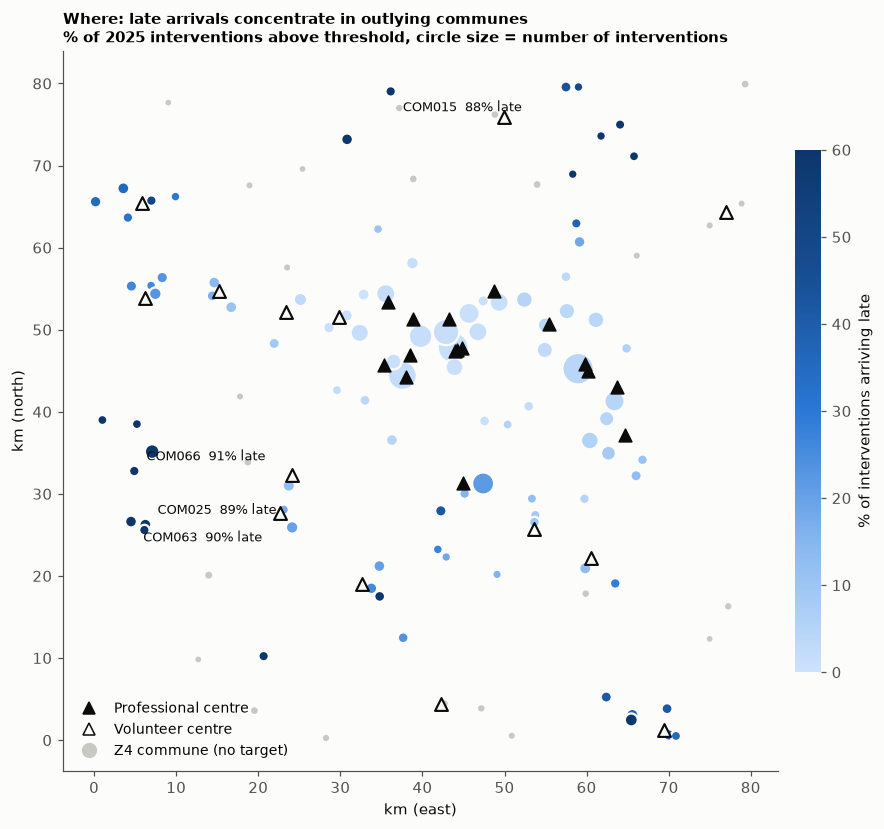

In [7]:
fg.map_late_share(interventions, raw)   # the four worst communes

,night 0h to 6h,peak 12h to 19h,worst hour
regime,,,
professionnel,98.6,93.6,14h
volontaire,68.7,62.0,12h


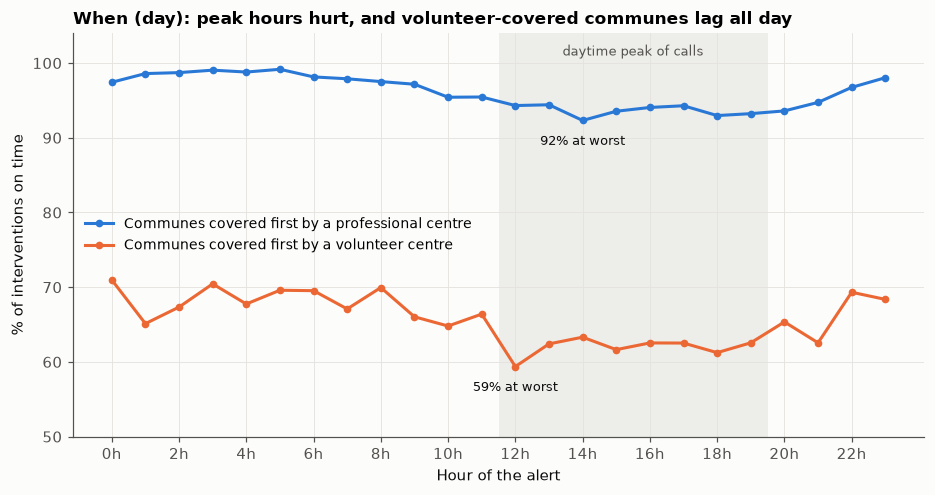

In [8]:
fg.hourly_on_time(interventions, raw)

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
reason,,,,,,,,,,,,
INC,7,12,23,26,26,33,42,33,33,22,18,15
SAP,0,4,6,15,35,69,77,56,36,14,8,2
AVP,1,0,0,1,3,21,16,7,6,3,1,1


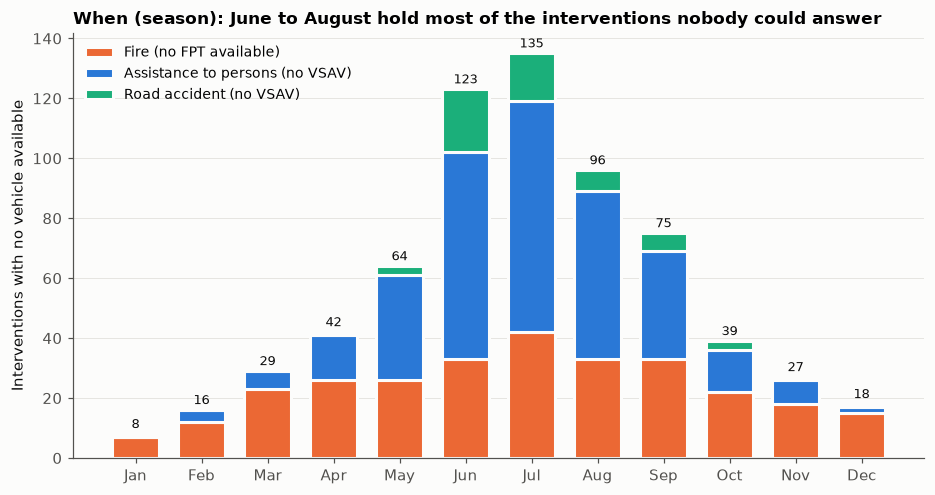

In [9]:
fg.monthly_unfulfilled(interventions)

**Reading the figures**
- **Where.** Lateness is mostly geographic. Communes covered first by a volunteer centre are on time about 65% of
  the time, against 95% for professional ones. The worst are outlying Z3 communes, up to 91% late.
- **When in the day.** Professional areas slip from 99% at night to about 92% between 12h and 20h, when calls peak.
  Volunteer areas stay low around the clock: their centres take about 6 min to leave against 2 min, and drive
  about 15 min against 8. Their problem is structural, not a rush-hour effect.
- **When in the year.** June to August hold 53% of the interventions nobody could answer. The summer peak comes
  from assistance to persons; unanswered fires are spread over the whole year.

## 6. Which centre answers first in each commune

**Rule:** the official deployment plan, `rang = 1`. Every centre has a VSAV, so this centre answers first for
assistance to persons and road accidents. A fire needs an FPT and 14 volunteer centres have none, so for fires the
first centre is the first one in the same plan order that holds an FPT (`first_centre_fire`).

In [10]:
table = h.first_centre_table(raw, interventions)
table.to_csv(h.RESULTS / "commune_first_centre.csv", index=False)   # all 120 communes
table.head(10)

,insee,commune,zone,first_centre,first_centre_fire,nearest_centre,observed_vsav,plan_share_vsav_pct,observed_fpt,plan_share_fpt_pct
0,25001,COM001,Z2,CIS07,CIS07,CIS07,CIS07,53.5,CIS07,66.7
1,25002,COM002,Z3,CIS29,CIS19,CIS29,CIS29,74.6,CIS19,90.0
2,25003,COM003,Z1,CIS20,CIS20,CIS20,CIS20,48.1,CIS20,74.8
3,25004,COM004,Z2,CIS01,CIS01,CIS19,CIS01,73.1,CIS01,65.9
4,25005,COM005,Z4,CIS26,CIS23,CIS26,CIS26,96.9,CIS23,75.0
5,25006,COM006,Z3,CIS24,CIS22,CIS24,CIS24,65.9,CIS22,71.4
6,25007,COM007,Z2,CIS22,CIS22,CIS22,CIS22,63.6,CIS22,62.4
7,25008,COM008,Z3,CIS09,CIS22,CIS09,CIS09,71.3,CIS22,67.7
8,25009,COM009,Z4,CIS19,CIS19,CIS29,CIS19,55.3,CIS19,63.6
9,25010,COM010,Z3,CIS14,CIS30,CIS14,CIS14,74.4,CIS30,48.1


In [11]:
ranks = raw["plan_deploiement"].set_index(["insee", "code_cis"])["rang"]
answered = interventions.dropna(subset=["first_centre"])
rank_used = ranks.reindex(pd.MultiIndex.from_arrays([answered["insee"], answered["first_centre"]]))
print("Plan rank of the centre that arrived first (% of interventions):",
      rank_used.value_counts(normalize=True).sort_index().mul(100).round(1).to_dict())

pd.Series({
    "VSAV: most frequent first centre = plan rang 1": (table["observed_vsav"] == table["first_centre"]).sum(),
    "Fire: most frequent first centre = first FPT holder in plan": (table["observed_fpt"] == table["first_centre_fire"]).sum(),
    "VSAV: most frequent first centre = nearest centre": (table["observed_vsav"] == table["nearest_centre"]).sum(),
}).to_frame("communes out of 120")

Plan rank of the centre that arrived first (% of interventions): {1: 63.9, 2: 18.7, 3: 7.4, 4: 3.7, 5: 2.5, 6: 1.6, 7: 1.1, 8: 1.0}


,communes out of 120
VSAV: most frequent first centre = plan rang 1,120
Fire: most frequent first centre = first FPT holder in plan,117
VSAV: most frequent first centre = nearest centre,85


**How I checked the rule**
- The plan's rank 1 arrives first in 64% of interventions, then rank 2, 3 and so on in decreasing order. That is
  what an ordered plan looks like when the first centre is sometimes busy.
- For VSAV, the most frequent first centre is plan rang 1 in **all 120 communes**. The "nearest centre" rule fits
  only 85, so the plan, not distance, is what really applies.
- For fires it fits 117 of 120. The three misses are isolated Z4 communes with 2 to 8 fires in the year.
- Limit: the data has no return times, so I cannot isolate the moments when all vehicles were free. The most
  frequent first centre stands in for that.

## Summary

- **Indicators reproduced.** P90 SAP 25.51 min and 290 unfulfilled fires match exactly. Compliance is 86.46%
  against 86.45%, a one-second rounding effect on seven interventions.
- **Where and when.** Coverage is weakest in outlying communes served by volunteer centres, at all hours. Across the
  department it also dips between 12h and 20h, and unanswered calls peak in summer.
- **Commune table.** `results/commune_first_centre.csv` follows the official plan and is confirmed by the data.
- **For Act 2.** The calculation is validated, so it can be trusted to judge where extra vehicles help most.